## DATA200 Final Project



Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
batting_url = "https://raw.githubusercontent.com/pressdevin/DATA200---Final-Project/main/Batting.csv"
players_url = "https://raw.githubusercontent.com/pressdevin/DATA200---Final-Project/main/People.csv"
fielding_url = "https://raw.githubusercontent.com/pressdevin/DATA200---Final-Project/main/Fielding.csv"
people_info = pd.read_csv(players_url)
batting_info = pd.read_csv(batting_url)
fielding_info = pd.read_csv(fielding_url)[['playerID', 'POS']]

In [3]:
hitting_stats = pd.merge(batting_info, people_info, on='playerID', how='inner')
players_stats = pd.merge(fielding_info, hitting_stats, on='playerID', how='inner')
players_stats = players_stats[players_stats['POS'] != 'P']
print(players_stats.head())

     playerID POS  yearID  stint teamID lgID    G   AB    R    H  ...  \
81  aaronha01  OF    1954      1    ML1   NL  122  468   58  131  ...   
82  aaronha01  OF    1955      1    ML1   NL  153  602  105  189  ...   
83  aaronha01  OF    1956      1    ML1   NL  153  609  106  200  ...   
84  aaronha01  OF    1957      1    ML1   NL  151  615  118  198  ...   
85  aaronha01  OF    1958      1    ML1   NL  153  601  109  196  ...   

    nameLast    nameGiven  weight  height  bats  throws       debut  \
81     Aaron  Henry Louis   180.0    72.0     R       R  1954-04-13   
82     Aaron  Henry Louis   180.0    72.0     R       R  1954-04-13   
83     Aaron  Henry Louis   180.0    72.0     R       R  1954-04-13   
84     Aaron  Henry Louis   180.0    72.0     R       R  1954-04-13   
85     Aaron  Henry Louis   180.0    72.0     R       R  1954-04-13   

      bbrefID   finalGame   retroID  
81  aaronha01  1976-10-03  aaroh101  
82  aaronha01  1976-10-03  aaroh101  
83  aaronha01  1976-

In [4]:
players_stats['debut_year'] = pd.to_datetime(players_stats['debut']).dt.year
players_stats = players_stats[players_stats['debut_year'] >= 2004]
players_stats['debut_year'] = players_stats['debut_year'].astype(int)

players_stats['years_in'] = players_stats['yearID'] - players_stats['debut_year']

In [5]:
players_stats = players_stats[players_stats['stint'] == 1]


In [6]:
columns_to_drop = ['POS', 'stint', 'teamID', 'lgID', 'birthYear', 'birthMonth', 'birthDay',
                   'birthCity', 'birthCountry', 'birthState', 'deathYear', 'deathMonth',
                   'deathDay', 'deathCity', 'deathCountry', 'deathState', 'nameLast',
                   'nameFirst', 'throws', 'debut', 'finalGame', 'bbrefID', 'retroID']
players_stats = players_stats.drop(columns=columns_to_drop)
print(players_stats.head())

       playerID  yearID    G   AB   R   H  2B  3B  HR   RBI  ...   SH   SF  \
2448  abercre01    2006  111  255  39  54  12   2   5  24.0  ...  4.0  1.0   
2449  abercre01    2007   35   76  16  15   3   0   2   5.0  ...  0.0  0.0   
2450  abercre01    2008   34   55  10  17   5   0   2   5.0  ...  1.0  1.0   
2451  abercre01    2006  111  255  39  54  12   2   5  24.0  ...  4.0  1.0   
2452  abercre01    2007   35   76  16  15   3   0   2   5.0  ...  0.0  0.0   

      GIDP  ID          nameGiven  weight  height  bats  debut_year  years_in  
2448   2.0  23  Reginald Damascus   215.0    75.0     R        2006         0  
2449   1.0  23  Reginald Damascus   215.0    75.0     R        2006         1  
2450   0.0  23  Reginald Damascus   215.0    75.0     R        2006         2  
2451   2.0  23  Reginald Damascus   215.0    75.0     R        2006         0  
2452   1.0  23  Reginald Damascus   215.0    75.0     R        2006         1  

[5 rows x 26 columns]


In [7]:
players_stats = players_stats.drop_duplicates()

In [8]:
players_stats['1B'] = players_stats['H'] - (players_stats['2B'] + players_stats['3B'] + players_stats['HR'])

players_stats['uBB'] = players_stats['BB'] - players_stats['IBB']

players_stats['wOBA'] = (0.69*players_stats['uBB']+0.722*players_stats['HBP']+0.888*players_stats['1B']+1.271*players_stats['2B']+1.616*players_stats['3B']+2.101*players_stats['HR'])/(players_stats['AB']+players_stats['BB']-players_stats['IBB']+players_stats['SF']+players_stats['HBP'])

In [9]:
MIN_AB = 100
MIN_G  = 30

players_stats = players_stats[(players_stats['AB'] >= MIN_AB) & (players_stats['G'] >= MIN_G)]

In [10]:
players_stats = players_stats.sort_values(['playerID', 'yearID'])

players_stats['woba_prev_year'] = players_stats.groupby('playerID')['wOBA'].shift(1)

players_stats['woba_yoy_pct'] = ((players_stats['wOBA'] - players_stats['woba_prev_year']) / players_stats['woba_prev_year'])*100

BREAKOUT_THRESHOLD = players_stats[players_stats['yearID'] < 2024]['woba_yoy_pct'].quantile(0.75)

players_stats['breakout'] = (players_stats['woba_yoy_pct'] >= BREAKOUT_THRESHOLD).astype(int)

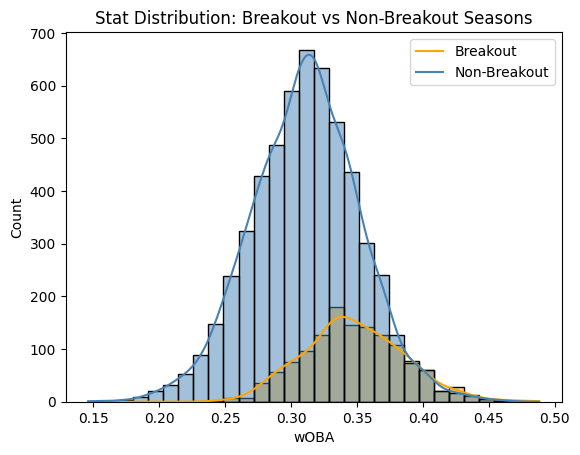

In [11]:
sns.histplot(data=players_stats, x='wOBA', hue='breakout',
             kde=True, bins=30, palette={0: 'steelblue', 1: 'orange'})

plt.title('Stat Distribution: Breakout vs Non-Breakout Seasons')
plt.xlabel('wOBA')
plt.ylabel('Count')
plt.legend(labels=['Breakout', 'Non-Breakout'])
plt.show()

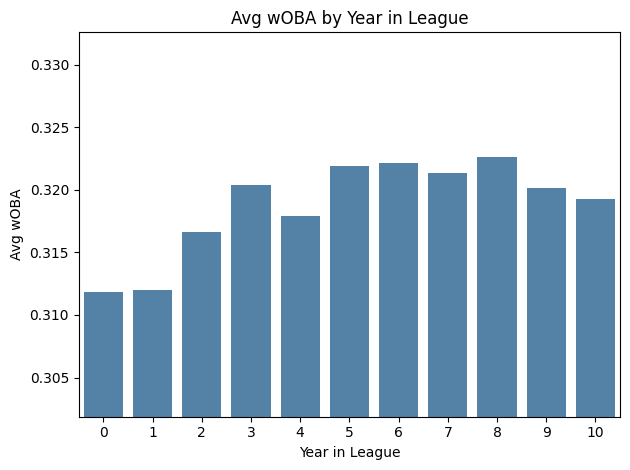

In [12]:
avg_players_stats = players_stats[players_stats['years_in'] <= 10].groupby('years_in')['wOBA'].mean().reset_index()

sns.barplot(data=avg_players_stats, x='years_in', y='wOBA', color='steelblue')

plt.title('Avg wOBA by Year in League')
plt.xlabel('Year in League')
plt.ylabel('Avg wOBA')

plt.ylim(avg_players_stats['wOBA'].min() - 0.01, avg_players_stats['wOBA'].max() + 0.01)

plt.tight_layout()
plt.show()

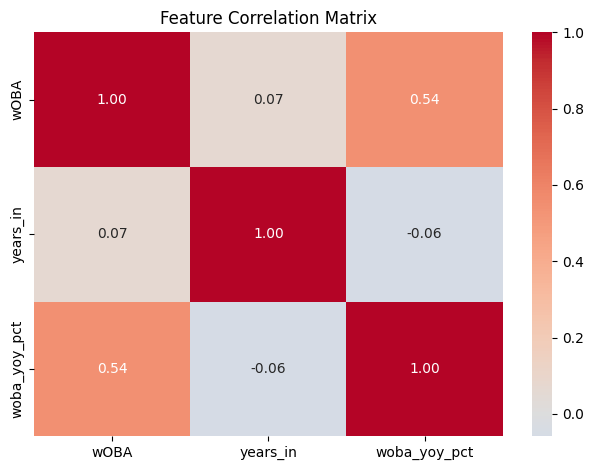

In [13]:
#WILL UPDATE AFTER FEATURE ENGINNERING
corr_cols = ['wOBA', 'years_in', 'woba_yoy_pct']

corr = players_stats[corr_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()